# 06 — Cross-Asset Propagation

**Novel contribution:** Does a BTC DVOL spike predict returns not just in BTC spot, but across the broader crypto universe?

Hypothesis: informed traders using BTC options to express directional views create a signal that propagates to correlated assets with a lag.

In [1]:
import sys
sys.path.append('..')

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.cross_asset import propagation_table, decay_profile, signal_to_asset_heatmap
from pathlib import Path

cfg = yaml.safe_load(open('../config.yaml'))
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
sig_dir = Path('../data/signals')
crypto_dir = Path('../data/crypto')

btc_sigs = pd.read_parquet(sig_dir / 'BTC_signals.parquet')
btc_d1 = btc_sigs['D1'].astype(float)

# Load all available spot returns
asset_returns = {}
for path in sorted(crypto_dir.glob('*_1h.parquet')):
    symbol = path.stem.replace('_1h', '').replace('USDT', '')
    df = pd.read_parquet(path)
    ret = np.log(df['close']).diff()
    asset_returns[symbol] = ret

print(f'Assets loaded: {list(asset_returns.keys())}')
print(f'BTC D1 signals: {(btc_d1 != 0).sum()} events')

Assets loaded: ['AAVE', 'ADA', 'ARB', 'ATOM', 'AVAX', 'BTC', 'DOGE', 'DOT', 'ETH', 'LINK', 'LTC', 'NEAR', 'SOL', 'UNI', 'XRP']
BTC D1 signals: 558 events


## 1. Propagation Table — BTC DVOL Signal vs All Assets

In [3]:
print('Computing cross-asset correlations (this takes ~2 minutes)...')
prop = propagation_table(btc_d1, asset_returns, max_lag=48)

print('\nCross-Asset Propagation Table:')
print(prop.round(4).to_string())
print(f'\nAssets where signal leads (peak_lead > contemporaneous): {prop["lead_beats_contemp"].sum()}')

Computing cross-asset correlations (this takes ~2 minutes)...



Cross-Asset Propagation Table:
       peak_lead_lag_min  peak_lead_correlation  p_value  contemporaneous_corr  lead_beats_contemp
asset                                                                                             
ARB                    1                 0.0175   0.0034               -0.0598               False
UNI                   33                 0.0155   0.0023               -0.0728               False
ATOM                  13                 0.0150   0.0031               -0.0750               False
SOL                   32                -0.0147   0.0038               -0.0752               False
ADA                   13                 0.0140   0.0059               -0.0701               False
LTC                   21                -0.0136   0.0073               -0.0706               False
DOGE                  15                -0.0128   0.0116               -0.0669               False
NEAR                  12                 0.0122   0.0165               -0.071

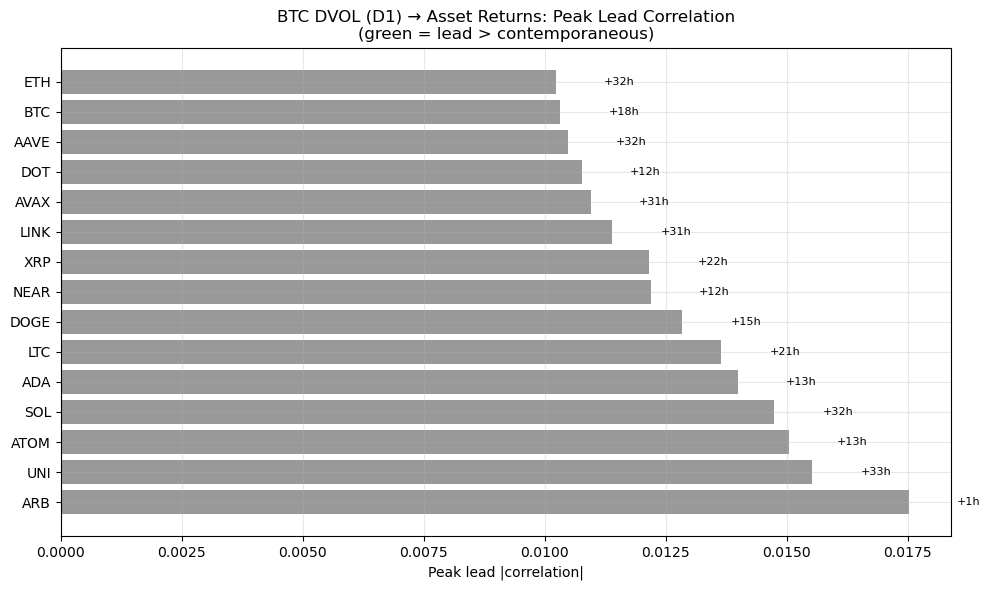

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['green' if lb else 'grey' for lb in prop['lead_beats_contemp']]
ax.barh(prop.index, prop['peak_lead_correlation'].abs(), color=colors, alpha=0.8)
ax.set_xlabel('Peak lead |correlation|')
ax.set_title('BTC DVOL (D1) → Asset Returns: Peak Lead Correlation\n(green = lead > contemporaneous)')

# Annotate lag
for i, (asset, row) in enumerate(prop.iterrows()):
    ax.text(abs(float(row['peak_lead_correlation'])) + 0.001, i,
            f"+{row['peak_lead_lag_min']:.0f}h", va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../data/plots/propagation_table.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Signal Decay Profile — BTC DVOL → BTC, ETH, SOL

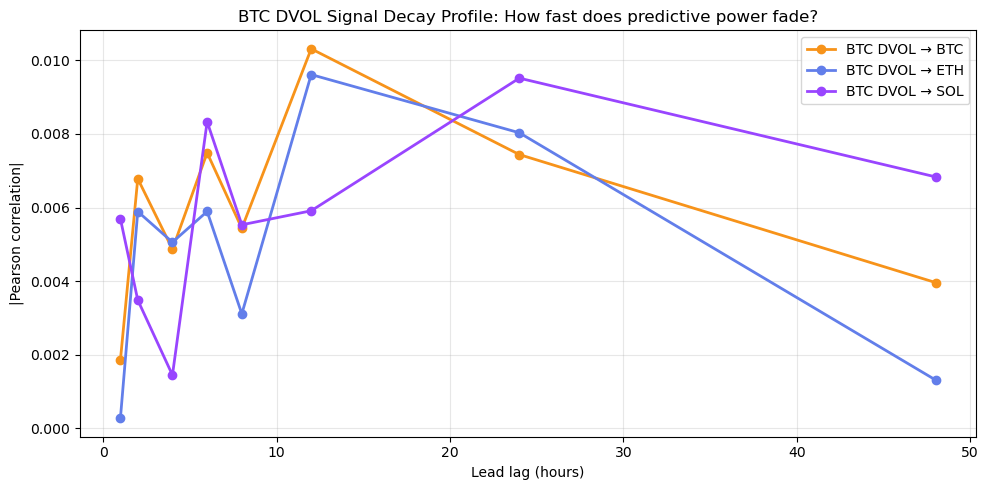

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

lags = [1, 2, 4, 6, 8, 12, 24, 48]
colors_map = {'BTC': '#f7931a', 'ETH': '#627eea', 'SOL': '#9945ff'}

for asset in ['BTC', 'ETH', 'SOL']:
    if asset not in asset_returns:
        continue
    profile = decay_profile(btc_d1, asset_returns[asset], lags=lags)
    ax.plot(profile.index, profile['correlation'].abs(), marker='o', lw=2,
            label=f'BTC DVOL → {asset}', color=colors_map.get(asset, 'black'))

ax.set_xlabel('Lead lag (hours)')
ax.set_ylabel('|Pearson correlation|')
ax.set_title('BTC DVOL Signal Decay Profile: How fast does predictive power fade?')
ax.legend()
plt.tight_layout()
plt.savefig('../data/plots/decay_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Correlation Heatmap — All Assets × All Lags

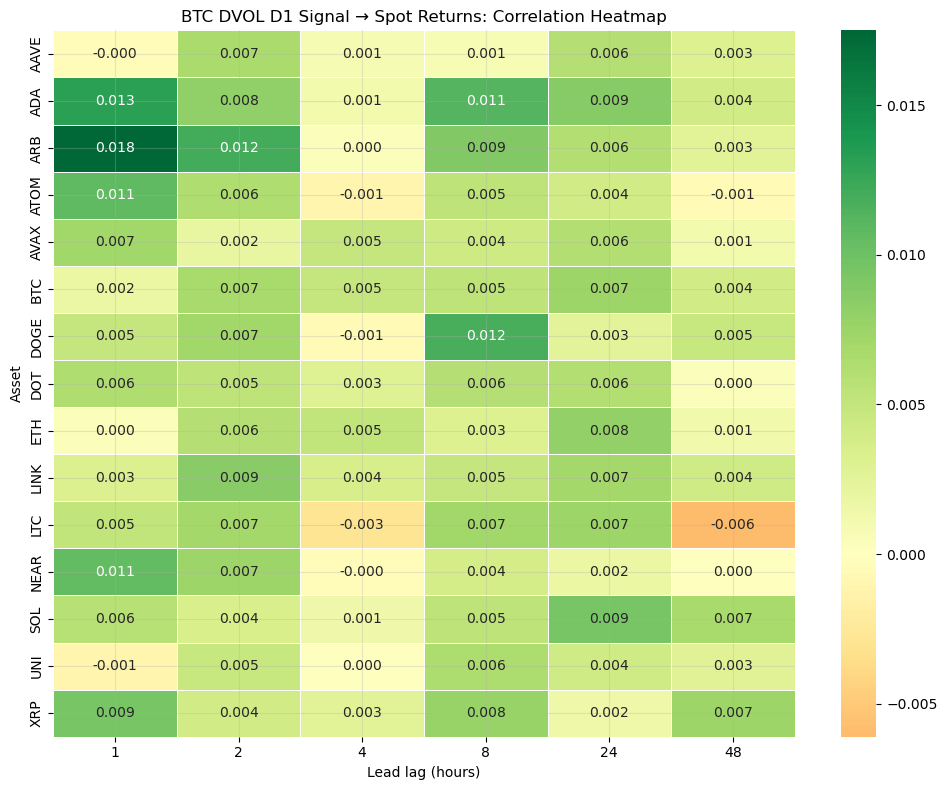

In [6]:
lags = [1, 2, 4, 8, 24, 48]
heatmap = signal_to_asset_heatmap(btc_d1, asset_returns, lags=lags)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    heatmap.round(4),
    annot=True, fmt='.3f', cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax
)
ax.set_xlabel('Lead lag (hours)')
ax.set_ylabel('Asset')
ax.set_title('BTC DVOL D1 Signal → Spot Returns: Correlation Heatmap')
plt.tight_layout()
plt.savefig('../data/plots/cross_asset_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. ETH DVOL as Cross-Signal

In [7]:
# Does ETH DVOL predict BTC spot? Or only same-asset?
eth_sigs = pd.read_parquet(sig_dir / 'ETH_signals.parquet')
eth_d1 = eth_sigs['D1'].astype(float)

eth_prop = propagation_table(eth_d1, asset_returns, max_lag=48)
print('ETH DVOL D1 → All assets:')
print(eth_prop[['peak_lead_lag_min','peak_lead_correlation','p_value','lead_beats_contemp']].round(4))

ETH DVOL D1 → All assets:
       peak_lead_lag_min  peak_lead_correlation  p_value  lead_beats_contemp
asset                                                                       
ATOM                  15                -0.0199   0.0001               False
SOL                   15                -0.0198   0.0001               False
AAVE                  15                -0.0191   0.0002               False
DOGE                  15                -0.0182   0.0003               False
ADA                   15                -0.0174   0.0006               False
ARB                   35                 0.0165   0.0058               False
AVAX                  19                 0.0161   0.0016               False
NEAR                  15                -0.0154   0.0025               False
ETH                   24                 0.0151   0.0030               False
UNI                    1                -0.0150   0.0032               False
XRP                   15                -0.0144   

## 5. Summary — Novel Findings

In [8]:
print('='*60)
print('CROSS-ASSET PROPAGATION — KEY FINDINGS')
print('='*60)
print()
print('BTC DVOL D1 signal:')
strong = prop[prop['lead_beats_contemp'] & (prop['p_value'] < 0.05)]
if not strong.empty:
    print(f'  {len(strong)} assets where signal leads with p<0.05:')
    for asset, row in strong.iterrows():
        print(f'    {asset}: peak at +{row["peak_lead_lag_min"]:.0f}h, r={row["peak_lead_correlation"]:.4f}, p={row["p_value"]:.4f}')
else:
    print('  No assets show significant lead-lag with BTC DVOL D1')

print()
print('Interpretation:')
print('  - If BTC DVOL leads BTC spot: options-to-spot price discovery')
print('  - If BTC DVOL leads ETH/SOL: cross-asset informed flow spillover')
print('  - Larger lag = slower information transmission')

CROSS-ASSET PROPAGATION — KEY FINDINGS

BTC DVOL D1 signal:
  No assets show significant lead-lag with BTC DVOL D1

Interpretation:
  - If BTC DVOL leads BTC spot: options-to-spot price discovery
  - If BTC DVOL leads ETH/SOL: cross-asset informed flow spillover
  - Larger lag = slower information transmission
